<a href="https://colab.research.google.com/github/Symphoen1x/LearnAI-NLP/blob/main/other/practical_data_splitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Link AI assistant
(https://chat.deepseek.com/a/chat/s/aa75226b-b768-4fd9-8a01-ef894b23d54a)

## Train-Test Split(holdout method)

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

# Memuat dataset iris sebagai contoh
iris = load_iris()
X = iris.data  # Fitur
y = iris.target  # Target

# Konversi ke dataframe untuk visualisasi
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("5 sampel pertama:")
print(df.head())
print("\nJumlah total data:", len(df))

5 sampel pertama:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Jumlah total data: 150


In [2]:
from sklearn.model_selection import train_test_split

# Split data dengan perbandingan 70% training, 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nJumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


Jumlah data training: 105
Jumlah data testing: 45


In [3]:
import numpy as np

# Cek distribusi kelas pada data asli
print("\nDistribusi kelas data asli:")
print(np.bincount(y))

# Cek distribusi kelas pada data training
print("\nDistribusi kelas data training:")
print(np.bincount(y_train))

# Cek distribusi kelas pada data testing
print("\nDistribusi kelas data testing:")
print(np.bincount(y_test))


Distribusi kelas data asli:
[50 50 50]

Distribusi kelas data training:
[31 37 37]

Distribusi kelas data testing:
[19 13 13]


<ipython-input-4-48e96f38049e>:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(error_rates, labels=[f"Test {int(100*size)}%" for size in test_sizes])


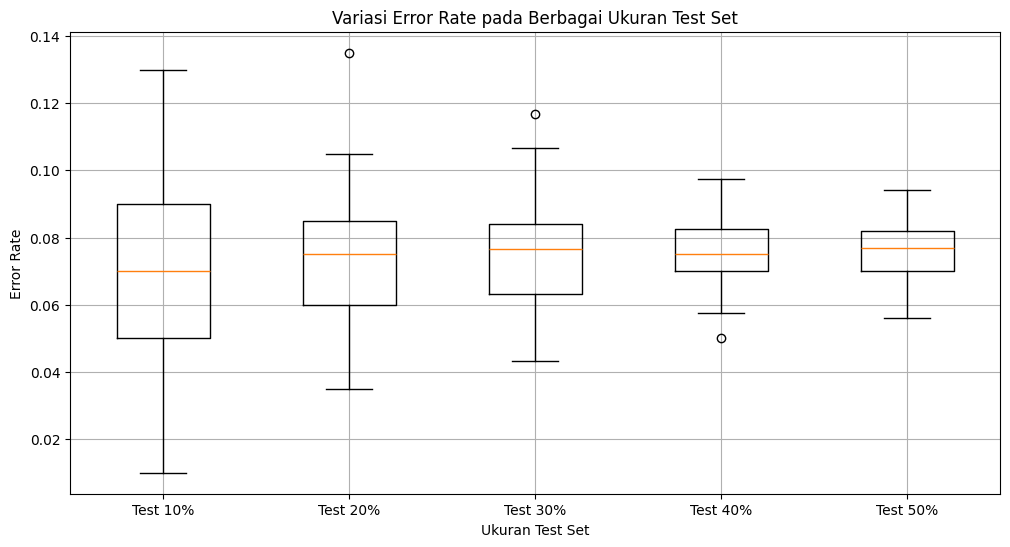

In [4]:
# Visualisasi Error Rate yang Berisik sebagai bukti bahwa holdout method memberikan estimasi eror rate ini karena ketergantunganya pada pembagian data acak yang tidak beruntung
# seperti: test set yang terlalu mudah/susah atau distribusi yang kurang representatif karena datanya kurang banyak
# cek: https://chat.deepseek.com/a/chat/s/aa75226b-b768-4fd9-8a01-ef894b23d54a
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Buat dataset sintetik
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.9, 0.1], random_state=42)

# Simpan error rates dari berbagai percobaan
error_rates = []
test_sizes = [0.1, 0.2, 0.3, 0.4, 0.5]

for test_size in test_sizes:
    temp_errors = []
    for _ in range(100):  # Ulang 100 kali untuk setiap test_size
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
        model = LogisticRegression()
        model.fit(X_train, y_train)
        error = 1 - model.score(X_test, y_test)
        temp_errors.append(error)
    error_rates.append(temp_errors)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.boxplot(error_rates, labels=[f"Test {int(100*size)}%" for size in test_sizes])
plt.title('Variasi Error Rate pada Berbagai Ukuran Test Set')
plt.ylabel('Error Rate')
plt.xlabel('Ukuran Test Set')
plt.grid(True)
plt.show()